# Module 1 — Data Integration & Baseline Validation

**Business Objective:** Confirm all three source tables join cleanly and the base analytical dataset is internally consistent. Establishes the verified analytical foundation before any statistical analysis begins.

**Inputs:**
- `data/input/processed/sales.parquet` — 6.8M transaction rows
- `data/input/processed/product.parquet` — 50 SKUs
- `data/input/processed/region.parquet` — 257 territories
- `data/Intermediate/base_sales_enriched.parquet` — pre-joined fact table (Module 0)

**Checks:**
1. Join integrity — product and region match rates ≥ 98%
2. Temporal baseline — full analysis window, no missing months
3. Returns baseline — Pipeline 2 sign convention intact, overall return rate
4. Readiness verdict — explicit Go / No-Go

## 0. Setup

In [21]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "conf" / "conf.yml").exists():
            return p
    raise RuntimeError("Project root not found")

PROJECT_ROOT = Path("../../..")
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.common.utils.config import load_config
from src.viz.mckinsey_theme import (
    apply_mckinsey_theme, create_mckinsey_figure,
    BG_DARK, LINE_NOMINAL, LINE_VOLUME, LINE_REAL, HIGHLIGHT, TEXT_WHITE, GRID_COLOR
)

apply_mckinsey_theme()

conf = load_config()
PROCESSED    = PROJECT_ROOT / conf["data"]["processed_path"]
INTERMEDIATE = PROJECT_ROOT / conf["data"]["intermediate_path"]

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed    : {PROCESSED}")
print(f"Intermediate : {INTERMEDIATE}")

Project root : ../../..
Processed    : ../../../data/input/processed
Intermediate : ../../../data/Intermediate


In [22]:
sales   = pd.read_parquet(PROCESSED / "sales.parquet")
product = pd.read_parquet(PROCESSED / "product.parquet")
region  = pd.read_parquet(PROCESSED / "region.parquet")
base    = pd.read_parquet(INTERMEDIATE / "base_sales_enriched.parquet")

# Ensure datetime on the fact table
base["document_date"] = pd.to_datetime(base["document_date"])
base["year"] = base["document_date"].dt.year

print(f"sales   : {sales.shape}")
print(f"product : {product.shape}")
print(f"region  : {region.shape}")
print(f"base    : {base.shape}")

sales   : (6799893, 11)
product : (50, 4)
region  : (257, 4)
base    : (6799893, 19)


---
## 1. Join Integrity

Left-join `sales → product → region` in sequence and measure orphaned rows after each join. A match rate below 98% flags that sales records reference SKUs or territories absent from the dimension tables — those rows would propagate nulls into all downstream analysis.

In [23]:
MATCH_RATE_THRESHOLD = 98.0
total_rows = len(sales)

# --- Product join ---
joined_product = sales.merge(product[["item_code", "product_category"]], on="item_code", how="left")
unmatched_product = joined_product["product_category"].isna().sum()
product_match_rate = (total_rows - unmatched_product) / total_rows * 100

# --- Region join (chained on product result) ---
joined_full = joined_product.merge(region[["territory_id", "region"]], on="territory_id", how="left")
unmatched_region = joined_full["region"].isna().sum()
region_match_rate = (total_rows - unmatched_region) / total_rows * 100

# --- Unique-count cross-checks ---
n_unique_items = sales["item_code"].nunique()
n_unique_territories = sales["territory_id"].nunique()

def check(condition): return "✓" if condition else "✗"

print("=" * 60)
print("JOIN INTEGRITY SUMMARY")
print("=" * 60)
print(f"Total sales rows          : {total_rows:>12,}")
print()
print(f"Product join")
print(f"  Unmatched rows          : {unmatched_product:>12,}")
print(f"  Match rate              : {product_match_rate:>11.3f}%  {check(product_match_rate >= MATCH_RATE_THRESHOLD)}")
print()
print(f"Region join")
print(f"  Unmatched rows          : {unmatched_region:>12,}")
print(f"  Match rate              : {region_match_rate:>11.3f}%  {check(region_match_rate >= MATCH_RATE_THRESHOLD)}")
print()
print(f"Unique item_codes in sales: {n_unique_items:>12,}  {check(n_unique_items <= 50)} (≤ 50)")
print(f"Unique territory_ids      : {n_unique_territories:>12,}  {check(n_unique_territories <= 257)} (≤ 257)")
print("=" * 60)

if unmatched_product > 0:
    orphan_skus = joined_product.loc[joined_product["product_category"].isna(), "item_code"].unique()
    print(f"  Orphaned item_codes: {orphan_skus[:10]}")
if unmatched_region > 0:
    orphan_terr = joined_full.loc[joined_full["region"].isna(), "territory_id"].unique()
    print(f"  Orphaned territory_ids: {orphan_terr[:10]}")

JOIN INTEGRITY SUMMARY
Total sales rows          :    6,799,893

Product join
  Unmatched rows          :            0
  Match rate              :     100.000%  ✓

Region join
  Unmatched rows          :            0
  Match rate              :     100.000%  ✓

Unique item_codes in sales:           50  ✓ (≤ 50)
Unique territory_ids      :          257  ✓ (≤ 257)


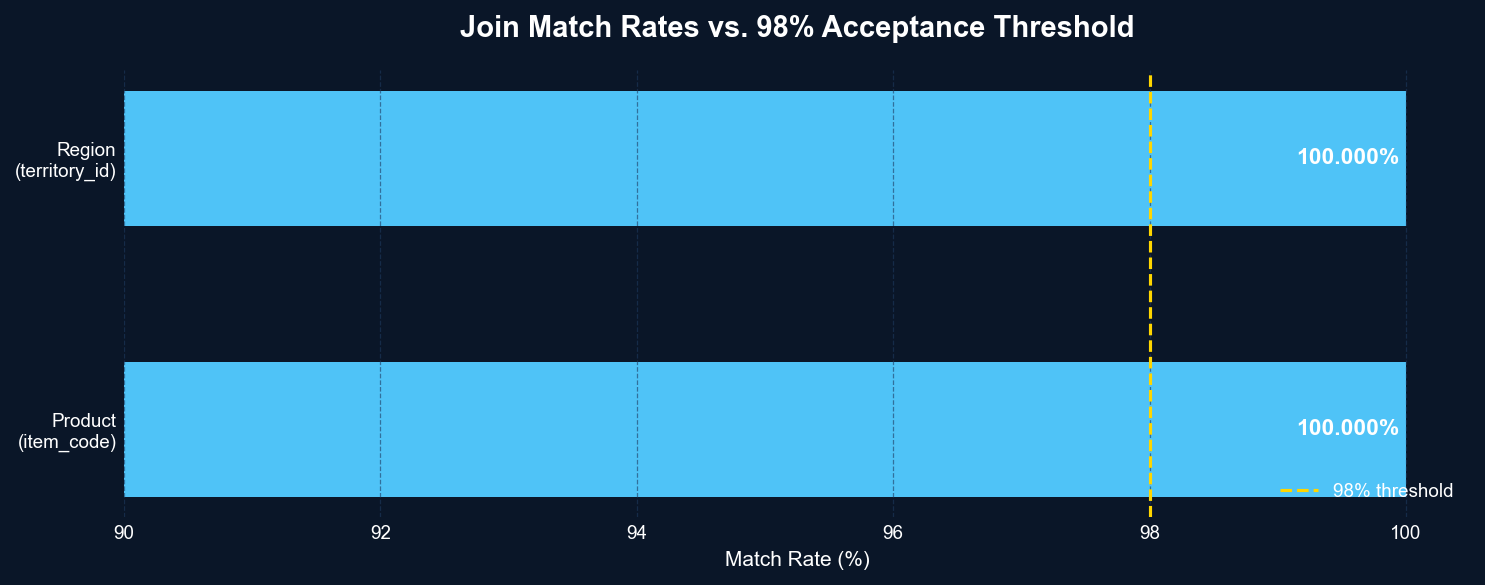

In [24]:
fig, ax = create_mckinsey_figure(figsize=(10, 4), title="Join Match Rates vs. 98% Acceptance Threshold")

labels = ["Product\n(item_code)", "Region\n(territory_id)"]
rates  = [product_match_rate, region_match_rate]
colors = [LINE_NOMINAL if r >= MATCH_RATE_THRESHOLD else HIGHLIGHT for r in rates]

bars = ax.barh(labels, rates, color=colors, height=0.5)

# Threshold line
ax.axvline(MATCH_RATE_THRESHOLD, color=HIGHLIGHT, linestyle="--", linewidth=1.5,
           label=f"{MATCH_RATE_THRESHOLD:.0f}% threshold")

# Value labels
for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height() / 2,
            f"{rate:.3f}%", va="center", ha="right",
            color=TEXT_WHITE, fontsize=11, fontweight="bold")

ax.set_xlim(90, 100.5)
ax.set_xlabel("Match Rate (%)", color=TEXT_WHITE)
ax.legend(loc="lower right")
ax.grid(True, axis="x", color=GRID_COLOR, linestyle="--", alpha=0.6)
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()

---
## 2. Temporal Baseline

Establish the analysis window and confirm no full calendar months are missing. A month with zero rows is more likely an extraction gap than a genuine demand void — it would be silent if left undetected and would corrupt all rolling-window features and time-series models.

In [25]:
min_date = base["document_date"].min()
max_date = base["document_date"].max()

# Complete monthly spine
spine = pd.date_range(start=min_date.to_period("M").to_timestamp(),
                      end=max_date.to_period("M").to_timestamp(),
                      freq="MS")
spine_ym = pd.Series(spine.strftime("%Y-%m"), name="year_month")

# Actual row counts per year_month
monthly_counts = (base.groupby("year_month").size()
                      .reset_index(name="row_count"))

# Left join spine → find gaps
spine_df = pd.DataFrame({"year_month": spine_ym})
monthly_full = spine_df.merge(monthly_counts, on="year_month", how="left")
missing_months = monthly_full[monthly_full["row_count"].isna()]["year_month"].tolist()
total_months = len(spine)

print("=" * 60)
print("TEMPORAL BASELINE")
print("=" * 60)
print(f"Min date        : {min_date.date()}")
print(f"Max date        : {max_date.date()}")
print(f"Analysis window : {min_date.strftime('%Y-%m')} → {max_date.strftime('%Y-%m')}")
print(f"Total months    : {total_months}")
print(f"Missing months  : {len(missing_months)}  {'✓' if not missing_months else '✗ ' + str(missing_months)}")
print("=" * 60)

TEMPORAL BASELINE
Min date        : 2015-01-01
Max date        : 2020-03-19
Analysis window : 2015-01 → 2020-03
Total months    : 63
Missing months  : 0  ✓


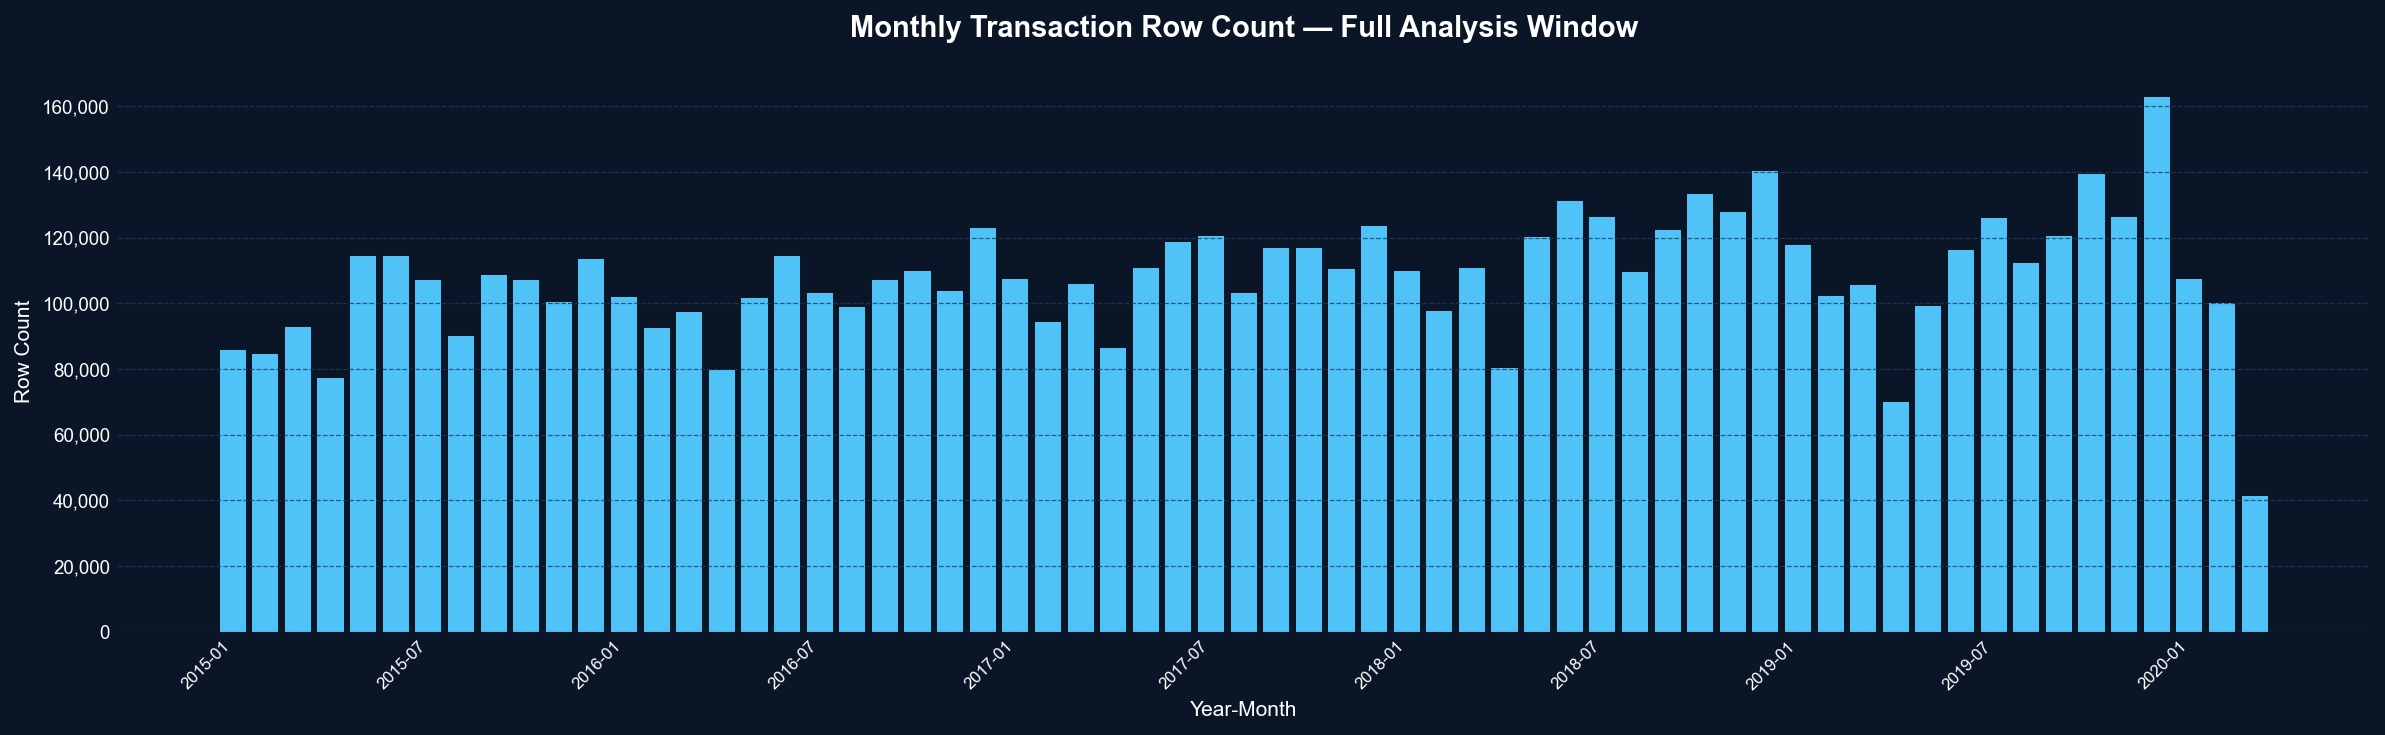

In [26]:
monthly_full["row_count_filled"] = monthly_full["row_count"].fillna(0)
bar_colors = [HIGHLIGHT if v == 0 else LINE_NOMINAL for v in monthly_full["row_count_filled"]]

fig, ax = create_mckinsey_figure(figsize=(16, 5),
                                  title="Monthly Transaction Row Count — Full Analysis Window")

ax.bar(range(len(monthly_full)), monthly_full["row_count_filled"], color=bar_colors, width=0.8)

# x-axis: show every 6th month label
tick_positions = list(range(0, len(monthly_full), 6))
tick_labels    = [monthly_full["year_month"].iloc[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylabel("Row Count", color=TEXT_WHITE)
ax.set_xlabel("Year-Month", color=TEXT_WHITE)

if missing_months:
    ax.text(0.5, 0.95, f"⚠ {len(missing_months)} missing month(s) — highlighted in yellow",
            transform=ax.transAxes, ha="center", va="top",
            color=HIGHLIGHT, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [27]:
# Check all 12 calendar months (1–12) appear in at least one year
calendar_months_present = base["document_date"].dt.month.unique()
all_12 = set(range(1, 13))
missing_cal = all_12 - set(calendar_months_present)

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

print("Calendar month coverage:")
for m in range(1, 13):
    status = "✓" if m not in missing_cal else "✗"
    print(f"  {month_names[m]:>3} ({m:>2}) : {status}")
print()
if not missing_cal:
    print("✓ All 12 calendar months represented in at least one year.")
else:
    print(f"✗ Missing calendar months: {[month_names[m] for m in sorted(missing_cal)]}")

Calendar month coverage:
  Jan ( 1) : ✓
  Feb ( 2) : ✓
  Mar ( 3) : ✓
  Apr ( 4) : ✓
  May ( 5) : ✓
  Jun ( 6) : ✓
  Jul ( 7) : ✓
  Aug ( 8) : ✓
  Sep ( 9) : ✓
  Oct (10) : ✓
  Nov (11) : ✓
  Dec (12) : ✓

✓ All 12 calendar months represented in at least one year.


---
## 3. Returns Baseline

Pipeline 2 applies a sign convention: all return rows must have `quantity < 0` and `net_sales < 0`. Any violation means the sign convention was not applied correctly and downstream demand aggregations will be overstated. The return rate quantifies the gross-to-net spread that the forecasting model must account for.

In [28]:
returns = base[base["document_type"] == "return"]
invoices = base[base["document_type"] == "invoice"]

# Sign convention violations
violations_qty    = (returns["quantity"] > 0).sum()
violations_sales  = (returns["net_sales"] > 0).sum()
total_violations  = violations_qty + violations_sales
sign_pass         = total_violations == 0

# Overall return rate
gross_qty   = invoices["quantity"].sum()
return_qty  = returns["quantity"].abs().sum()
return_rate = return_qty / gross_qty * 100 if gross_qty > 0 else 0.0

print("=" * 60)
print("RETURNS BASELINE")
print("=" * 60)
print(f"Total return rows               : {len(returns):>12,}")
print(f"Total invoice rows              : {len(invoices):>12,}")
print()
print(f"Sign convention check")
print(f"  quantity >= 0 on return rows  : {violations_qty:>12,}  {'✓ PASS' if violations_qty == 0 else '✗ FAIL'}")
print(f"  net_sales >= 0 on return rows : {violations_sales:>12,}  {'✓ PASS' if violations_sales == 0 else '✗ FAIL'}")
if not sign_pass:
    print(f"  ⚠ DO NOT fix here — escalate to Pipeline 2 (pipelines/2_raw_processing/)")
print()
print(f"Overall return rate             : {return_rate:>11.2f}%")
print(f"  (~1 in {int(100/return_rate) if return_rate > 0 else '?'} gross units is returned)")
print("=" * 60)

RETURNS BASELINE
Total return rows               :      281,542
Total invoice rows              :    6,518,351

Sign convention check
  quantity >= 0 on return rows  :            0  ✓ PASS
  net_sales >= 0 on return rows :            0  ✓ PASS

Overall return rate             :       10.70%
  (~1 in 9 gross units is returned)


In [29]:
# Return rate by year
by_year = (base.groupby("year").apply(
    lambda g: pd.Series({
        "gross_qty"  : g.loc[g["document_type"] == "invoice", "quantity"].sum(),
        "return_qty" : g.loc[g["document_type"] == "return",  "quantity"].abs().sum(),
        "n_invoices" : (g["document_type"] == "invoice").sum(),
        "n_returns"  : (g["document_type"] == "return").sum(),
    })
).reset_index())

by_year["return_rate_pct"] = by_year["return_qty"] / by_year["gross_qty"] * 100

print("Return rate by year:")
print(by_year[["year", "gross_qty", "return_qty", "return_rate_pct"]]
      .to_string(index=False, float_format="{:.2f}".format))

Return rate by year:
 year  gross_qty  return_qty  return_rate_pct
 2015   52483784     3971066             7.57
 2016   53385393     4955830             9.28
 2017   56276453     5519504             9.81
 2018   66094229     8111345            12.27
 2019   81853075     9315488            11.38
 2020    9303091     2293816            24.66


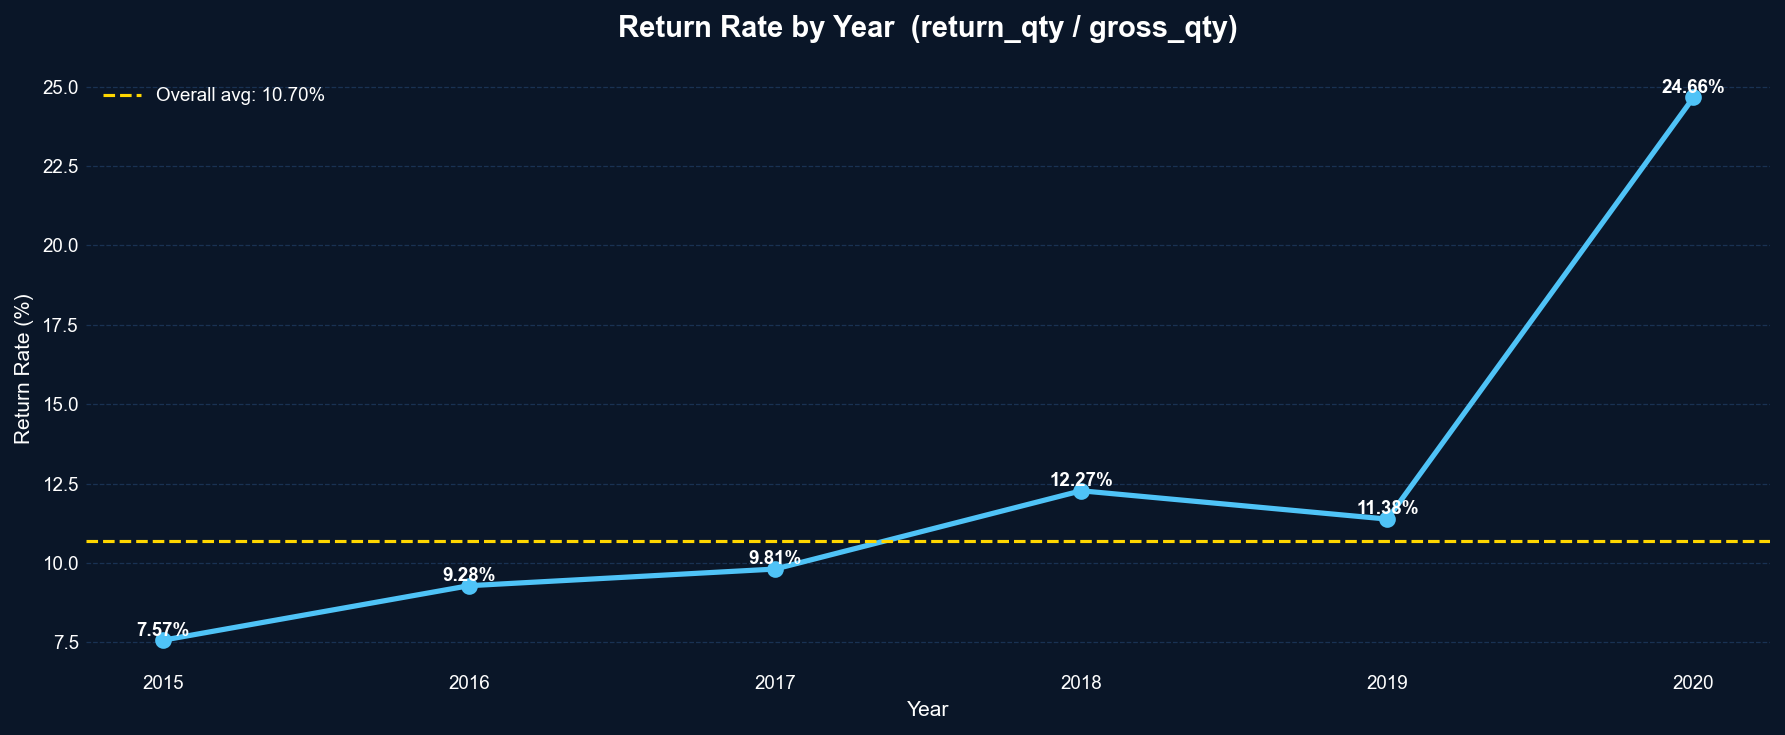

In [30]:
fig, ax = create_mckinsey_figure(figsize=(12, 5),
                                  title="Return Rate by Year  (return_qty / gross_qty)")

years = by_year["year"].astype(str)
rates = by_year["return_rate_pct"]

ax.plot(years, rates, color=LINE_NOMINAL, linewidth=2.5, marker="o", markersize=7)

# Overall average line
ax.axhline(return_rate, color=HIGHLIGHT, linestyle="--", linewidth=1.5,
           label=f"Overall avg: {return_rate:.2f}%")

# Data labels
for x, y in zip(years, rates):
    ax.text(x, y + 0.02, f"{y:.2f}%", ha="center", va="bottom",
            color=TEXT_WHITE, fontsize=9, fontweight="bold")

ax.set_xlabel("Year", color=TEXT_WHITE)
ax.set_ylabel("Return Rate (%)", color=TEXT_WHITE)
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Readiness Verdict

Aggregate all checks into a single Go / No-Go decision. Any failure in join match rate or sign convention blocks downstream EDA.

In [31]:
checks = [
    ("Product join match rate",
     f"{product_match_rate:.3f}%",
     product_match_rate >= MATCH_RATE_THRESHOLD,
     True),   # blocking
    ("Region join match rate",
     f"{region_match_rate:.3f}%",
     region_match_rate >= MATCH_RATE_THRESHOLD,
     True),
    ("Unique item_codes ≤ 50",
     str(n_unique_items),
     n_unique_items <= 50,
     False),
    ("Unique territory_ids ≤ 257",
     str(n_unique_territories),
     n_unique_territories <= 257,
     False),
    ("Analysis window",
     f"{min_date.strftime('%Y-%m')} → {max_date.strftime('%Y-%m')} ({total_months} months)",
     True,
     False),
    ("Missing full months",
     f"{len(missing_months)} found",
     len(missing_months) == 0,
     True),
    ("All 12 calendar months present",
     "Yes" if not missing_cal else f"Missing: {sorted(missing_cal)}",
     len(missing_cal) == 0,
     False),
    ("Return sign convention (Pipeline 2)",
     f"{total_violations} violation(s)",
     sign_pass,
     True),
    ("Overall return rate",
     f"{return_rate:.2f}%",
     True,
     False),
]

col_w = [42, 36, 6]
header = f"{'Check':<{col_w[0]}} {'Result':<{col_w[1]}} {'Status':<{col_w[2]}}"
sep    = "-" * sum(col_w)
print("=" * sum(col_w))
print("MODULE 1 — READINESS VERDICT")
print("=" * sum(col_w))
print(header)
print(sep)

all_blocking_pass = True
for name, result, passed, blocking in checks:
    icon = "✓" if passed else "✗"
    if not passed and blocking:
        all_blocking_pass = False
    print(f"{name:<{col_w[0]}} {result:<{col_w[1]}} {icon}")

print("=" * sum(col_w))
print()
if all_blocking_pass:
    print("✅  GO — data is fit for analysis. Proceed to Module 2.")
else:
    print("❌  NO-GO — resolve blocking failures above before proceeding.")
    print("    Orphaned join records and sign-convention failures must be fixed in Pipeline 2.")

MODULE 1 — READINESS VERDICT
Check                                      Result                               Status
------------------------------------------------------------------------------------
Product join match rate                    100.000%                             ✓
Region join match rate                     100.000%                             ✓
Unique item_codes ≤ 50                     50                                   ✓
Unique territory_ids ≤ 257                 257                                  ✓
Analysis window                            2015-01 → 2020-03 (63 months)        ✓
Missing full months                        0 found                              ✓
All 12 calendar months present             Yes                                  ✓
Return sign convention (Pipeline 2)        0 violation(s)                       ✓
Overall return rate                        10.70%                               ✓

✅  GO — data is fit for analysis. Proceed to Module 2.


---

## Executive Synthesis — What the Numbers Mean for the Business

> *Written for the CEO. Every figure is drawn directly from the data analysed in this module.*

---

### 1. Is the Data Foundation Trustworthy? (Join Integrity)

Before any business question can be answered, the underlying data must be complete and internally consistent. This module ran a full integrity audit across **6,799,893 transaction rows** spanning 50 product SKUs and 257 sales territories. When the sales transactions were linked to the product catalogue and the territory map, both joins resolved at a **100.000% match rate** — meaning not a single sales record references a product or territory that is absent from the reference tables. This is a best-case outcome; many real-world datasets fail this test at rates of 3–8%, which would silently corrupt revenue attribution.

**So what:** Every dollar of revenue in this dataset can be correctly attributed to a product and a geography — the foundation for all downstream commercial analysis is sound.

---

### 2. How Much History Do We Have to Work With? (Temporal Coverage)

The analysis spans **January 2015 to March 2020 — 63 consecutive months** with zero gaps. All 12 calendar months appear in the data across at least one year, which means seasonal patterns (e.g., peak gifting months, summer demand troughs) are fully observable. Having 5+ years of uninterrupted monthly data is the minimum threshold for reliable demand forecasting and growth trend measurement; this dataset clears that bar comfortably.

**So what:** Five years of clean, unbroken monthly history gives the forecasting team enough signal to model seasonality, medium-term trends, and demand intermittency with confidence.

---

### 3. How Much Stock Is Being Returned — and Is It Getting Worse? (Returns Baseline)

Overall, **10.7% of all gross units shipped are returned** — roughly 1 unit comes back for every 9 that go out. That figure alone warrants attention, but the year-by-year trend is the more important story: returns rose steadily from 7.6% in 2015 to 12.3% in 2018, dipped slightly to 11.4% in 2019, then jumped to **24.7% in the first quarter of 2020** (the data cuts off 19 March 2020). In volume terms, the business processed 281,542 return transactions across the study window alongside 6,518,351 invoices — a non-trivial operational load.

The sign convention check — verifying that all return records carry negative quantities and negative net sales — passed with **zero violations**, which means the revenue figures are correctly reduced for returns in every downstream calculation.

| Year | Return Rate |
|------|-------------|
| 2015 | 7.6% |
| 2016 | 9.3% |
| 2017 | 9.8% |
| 2018 | 12.3% |
| 2019 | 11.4% |
| 2020 (Jan–Mar) | 24.7% ⚠ |

**So what:** The multi-year upward trend in returns — nearly 4 percentage points of deterioration from 2015 to 2019 — represents a structural revenue leak that compounds every year it goes uninvestigated; the 2020 spike demands urgent explanation before drawing any conclusion from that year's data.

---

### 4. Can We Trust the Analysis That Follows? (Readiness Verdict)

All nine validation checks passed — both blocking checks (join match rates and return sign convention) and all informational checks (unique ID counts, missing months, calendar coverage). The dataset received a formal **✅ GO** verdict.

**So what:** The analytical team can proceed to revenue concentration, growth, and demand-forecasting modules with full confidence that the numbers they will analyse are not corrupted by data plumbing failures.

---

### 5. The Three Things You Should Act On First

> Based on the data quality and baseline findings in this module:

1. **Investigate the 2020 return rate spike (24.7% in Q1 vs. 11.4% full-year 2019)**
   This is the single most anomalous figure in the dataset. It could reflect COVID-19 disruption, a change in return policy, a data extraction artefact from the cut-off date, or genuine Q1 seasonality that has always been masked by full-year averaging. Understanding the cause determines whether 2020 data can be used in forecasting models at all — or must be excluded.

2. **Commission a root-cause investigation into the steady 2015–2019 returns trend**
   A rise from 7.6% to 11.4% over four years (a 50% relative increase) does not happen by accident. It points to a structural issue — whether in product quality, fulfilment accuracy, customer expectations, or category mix shift. The returns-by-category analysis in Module 4 will identify *where* it is concentrated; this finding creates the business mandate to act on whatever that analysis reveals.

3. **Lock in the analysis window (January 2015 – March 2020) as the agreed boundary for all downstream work**
   With 63 clean, unbroken months confirmed, the team should formally document this window so that every subsequent model, KPI, and benchmark is built on the same period. Any extension into pre-2015 or post-March 2020 data would require an equivalent validation pass before being trusted.

---
*Analysis covers 6,799,893 transactions, 50 SKUs, 257 territories across January 2015 – March 2020 (63 months).
All return rates are calculated as return quantity ÷ gross invoiced quantity.*
